# Learning the Physics with the Machine that Learned It

This notebook demonstrates how to learn interpretable physics relationships from SQuADDS:

1. **Explainable Boosting Machines (EBMs)** - Glass-box models that reveal feature importance
2. **Symbolic Regression (PySR)** - Discovers closed-form mathematical equations

### Datasets

We use two datasets - one with fixed EJ and one with variable EJ. The fixed EJ dataset allows us to isolate the effect of EJ variation on the Hamiltonian parameters so that we can focus only on the geometric parameters.

The variable EJ dataset is used to see if the system can learn the physics of the system even when the EJ is varied.

In [ ]:
# Standard library
import warnings
import pickle
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from interpret.glassbox import ExplainableBoostingRegressor

# Symbolic Regression
try:
    from pysr import PySRRegressor
    PYSR_AVAILABLE = True
except ImportError:
    print("PySR not installed. Symbolic regression will be skipped.")
    print("Install with: pip install pysr")
    PYSR_AVAILABLE = False

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✓ All imports successful")
print(f"  PySR available: {PYSR_AVAILABLE}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
✓ All imports successful
  PySR available: True


Configuration flags

In [2]:
# Data regeneration flags (set to True to overwrite existing data)
REGENERATE_DATASET_1 = False  # Fixed-EJ dataset
REGENERATE_DATASET_2 = False  # Variable-EJ dataset

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output directories
DATA_DIR = Path('data')
FIG_DIR = Path('figures/physics_learning')
CHECKPOINT_DIR = Path('checkpoints/physics_learning')

DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Figure directory: {FIG_DIR}")
print(f"Checkpoint directory: {CHECKPOINT_DIR}")

Data directory: data
Figure directory: figures/physics_learning
Checkpoint directory: checkpoints/physics_learning


Parameter definitions

In [3]:
# Dataset 1: Fixed EJ (original)
DESIGN_PARAMS_D1 = [
    'cross_length',      # Length of transmon cross (μm)
    'claw_length',       # Length of claw coupler (μm)
    'coupling_length',   # Length of coupling region (μm)
    'total_length',      # Total cavity length (μm)
    'ground_spacing',    # Gap to ground plane (μm)
]

# Dataset 2: Variable EJ (with sqrt_EJ as design param, fixed ground_spacing)
FIXED_GROUND_SPACING = 4.1  # μm
DESIGN_PARAMS_D2 = [
    'cross_length',
    'claw_length',
    'coupling_length',
    'total_length',
    'sqrt_EJ_GHz',       # √(EJ) in √GHz
]

# Hamiltonian parameters (same for both datasets)
HAMILTONIAN_PARAMS = [
    'qubit_frequency_GHz',   
    'anharmonicity_MHz',     
    'cavity_frequency_GHz',  
    'kappa_kHz',             
    'g_MHz',                 
]

print("Dataset 1 design parameters:", DESIGN_PARAMS_D1)
print("Dataset 2 design parameters:", DESIGN_PARAMS_D2)
print("Hamiltonian parameters:", HAMILTONIAN_PARAMS)

Dataset 1 design parameters: ['cross_length', 'claw_length', 'coupling_length', 'total_length', 'ground_spacing']
Dataset 2 design parameters: ['cross_length', 'claw_length', 'coupling_length', 'total_length', 'sqrt_EJ_GHz']
Hamiltonian parameters: ['qubit_frequency_GHz', 'anharmonicity_MHz', 'cavity_frequency_GHz', 'kappa_kHz', 'g_MHz']


## Training Dataset Creation

### Dataset 1: Fixed EJ
The dataset generated and used in [Tutorial-9](https://lfl-lab.github.io/SQuADDS/source/tutorials/Tutorial-9_Learing_the_Inverse_Design_Map.html) from SQuADDS

### Dataset 2: Variable EJ  
We want to vary EJ by ±20% and have the same structure as Dataset 1.

In [4]:
dataset1_path = DATA_DIR / 'training_data.parquet'

if REGENERATE_DATASET_1 or not dataset1_path.exists():
    print("Generating Dataset 1 from SQuADDS...")
    # Note: This requires SQuADDS to be installed and configured
    # For this notebook, we assume the data already exists
    raise FileNotFoundError(
        f"Dataset 1 not found at {dataset1_path}. "
        "Please run Tutorial-10 first to generate this data."
    )
else:
    print(f"Loading Dataset 1 from {dataset1_path}")
    df1 = pd.read_parquet(dataset1_path)

print(f"\nDataset 1 shape: {df1.shape}")
print(f"EJ unique values: {df1['EJ'].nunique() if 'EJ' in df1.columns else 'N/A'}")
if 'EJ' in df1.columns:
    ej_variation = (df1['EJ'].max() - df1['EJ'].min()) / df1['EJ'].mean() * 100
    print(f"EJ variation: {ej_variation:.2f}%")

Loading Dataset 1 from data/training_data.parquet

Dataset 1 shape: (133176, 13)
EJ unique values: 1
EJ variation: 0.00%


In [5]:
dataset2_path = DATA_DIR / 'training_data_v5_expanded.parquet'

if REGENERATE_DATASET_2 or not dataset2_path.exists():
    print("Generating Dataset 2 with EJ variation...")

    base_path = DATA_DIR / 'training_data.parquet'
    df_full = pd.read_parquet(base_path)
    print(f"Loaded base data: {len(df_full)} samples")
    
    # Filter to fixed ground_spacing
    df_base = df_full[df_full['ground_spacing'] == FIXED_GROUND_SPACING].copy()
    print(f"Filtered to ground_spacing = {FIXED_GROUND_SPACING} μm: {len(df_base)} samples")
    
    # EJ variation parameters
    EJ_VARIATION_PERCENT = 10
    N_EJ_SAMPLES = 10
    
    ej_multipliers = np.linspace(
        1 - EJ_VARIATION_PERCENT/100, 
        1 + EJ_VARIATION_PERCENT/100, 
        N_EJ_SAMPLES
    )
    print(f"\nCreating {N_EJ_SAMPLES} EJ variations with ±{EJ_VARIATION_PERCENT}% range")
    
    def recalculate_hamiltonian(row, ej_multiplier):
        """Recalculate Hamiltonian params when EJ changes."""
        new_row = row.copy()
        EJ_old = row['EJ']
        EJ_new = EJ_old * ej_multiplier
        new_row['EJ'] = EJ_new
        
        # Estimate EC from anharmonicity: α ≈ -EC
        EC = abs(row['anharmonicity_MHz']) / 1000  # Convert MHz to GHz
        
        # f_q = sqrt(8 * EJ * EC) - EC
        new_row['qubit_frequency_GHz'] = np.sqrt(8 * EJ_new * EC) - EC
        
        # α ≈ -EC (no leading EJ dependence)
        new_row['anharmonicity_MHz'] = -EC * 1000
        
        # g ∝ sqrt(EJ) at fixed geometry
        new_row['g_MHz'] = row['g_MHz'] * np.sqrt(EJ_new / EJ_old)
        
        return new_row
    
    # Generate expanded dataset
    expanded_dfs = []
    for mult in ej_multipliers:
        df_expanded = df_base.apply(lambda row: recalculate_hamiltonian(row, mult), axis=1)
        expanded_dfs.append(df_expanded)
    
    df2 = pd.concat(expanded_dfs, ignore_index=True)
    
    # Calculate sqrt_EJ
    df2['sqrt_EJ_GHz'] = np.sqrt(df2['EJ'])
    
    # Drop duplicates
    cols_to_check = DESIGN_PARAMS_D2 + HAMILTONIAN_PARAMS
    df2 = df2.drop_duplicates(subset=[c for c in cols_to_check if c in df2.columns])
    
    # Save
    df2.to_parquet(dataset2_path)
    print(f"\n✓ Saved Dataset 2 to {dataset2_path}")
else:
    print(f"Loading Dataset 2 from {dataset2_path}")
    df2 = pd.read_parquet(dataset2_path)
    
    # Ensure sqrt_EJ_GHz exists
    if 'sqrt_EJ_GHz' not in df2.columns and 'EJ' in df2.columns:
        df2['sqrt_EJ_GHz'] = np.sqrt(df2['EJ'])

print(f"\nDataset 2 shape: {df2.shape}")
print(f"EJ unique values: {df2['EJ'].nunique() if 'EJ' in df2.columns else 'N/A'}")
if 'EJ' in df2.columns:
    ej_variation = (df2['EJ'].max() - df2['EJ'].min()) / df2['EJ'].mean() * 100
    print(f"EJ variation: {ej_variation:.1f}%")
print(f"sqrt_EJ range: [{df2['sqrt_EJ_GHz'].min():.4f}, {df2['sqrt_EJ_GHz'].max():.4f}] √GHz")

Loading Dataset 2 from data/training_data_v5_expanded.parquet

Dataset 2 shape: (379500, 16)
EJ unique values: 60
EJ variation: 20.0%
sqrt_EJ range: [3.8355, 4.2404] √GHz


In [6]:
def verify_dataset(df, design_params, name):
    """Verify dataset quality and print summary."""
    print(f"\n{'='*60}")
    print(f"{name} Summary")
    print(f"{'='*60}")
    print(f"Shape: {df.shape}")
    
    # Check for missing values
    all_params = design_params + HAMILTONIAN_PARAMS
    missing = df[all_params].isnull().sum()
    if missing.sum() > 0:
        print(f"⚠ Missing values: {missing[missing > 0].to_dict()}")
    else:
        print("✓ No missing values")
    
    # Parameter ranges
    print("\nDesign Parameter Ranges:")
    for param in design_params:
        if param in df.columns:
            print(f"  {param}: [{df[param].min():.2f}, {df[param].max():.2f}]")
    
    print("\nHamiltonian Parameter Ranges:")
    for param in HAMILTONIAN_PARAMS:
        if param in df.columns:
            print(f"  {param}: [{df[param].min():.4f}, {df[param].max():.4f}]")

verify_dataset(df1, DESIGN_PARAMS_D1, "Dataset 1 (Fixed EJ)")
verify_dataset(df2, DESIGN_PARAMS_D2, "Dataset 2 (Variable EJ)")


Dataset 1 (Fixed EJ) Summary
Shape: (133176, 13)
✓ No missing values

Design Parameter Ranges:
  cross_length: [90.00, 420.00]
  claw_length: [70.00, 400.00]
  coupling_length: [100.00, 500.00]
  total_length: [2700.00, 4700.00]
  ground_spacing: [4.10, 10.00]

Hamiltonian Parameter Ranges:
  qubit_frequency_GHz: [3.2203, 7.1306]
  anharmonicity_MHz: [-525.8811, -88.9747]
  cavity_frequency_GHz: [4.9641, 9.8049]
  kappa_kHz: [21.8535, 988.7442]
  g_MHz: [11.2615, 146.0277]

Dataset 2 (Variable EJ) Summary
Shape: (379500, 16)
✓ No missing values

Design Parameter Ranges:
  cross_length: [90.00, 420.00]
  claw_length: [70.00, 400.00]
  coupling_length: [100.00, 500.00]
  total_length: [2700.00, 4700.00]
  sqrt_EJ_GHz: [3.84, 4.24]

Hamiltonian Parameter Ranges:
  qubit_frequency_GHz: [3.0530, 7.5324]
  anharmonicity_MHz: [-442.0787, -83.5973]
  cavity_frequency_GHz: [4.9641, 9.8049]
  kappa_kHz: [21.8535, 988.7442]
  g_MHz: [14.9461, 153.1552]


## Training Dataset Visualization

In [7]:
def plot_distributions(df, design_params, title_suffix):
    """Plot feature distributions as histograms."""
    all_params = design_params + HAMILTONIAN_PARAMS
    n_params = len(all_params)
    n_cols = 5
    n_rows = (n_params + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()
    
    for idx, param in enumerate(all_params):
        ax = axes[idx]
        if param in df.columns:
            data = df[param].dropna()
            n_unique = data.nunique()
            
            if n_unique < 2:
                ax.text(0.5, 0.5, f'Constant', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=14)
            else:
                ax.hist(data, bins=min(50, n_unique), alpha=0.7, 
                       color='steelblue', edgecolor='white')
            
            ax.set_title(param, fontsize=14, fontweight='bold')
            ax.tick_params(labelsize=10)
    
    # Hide unused axes
    for idx in range(len(all_params), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'Feature Distributions - {title_suffix}', fontsize=16, y=1.02)
    plt.tight_layout()
    return fig


def plot_correlation_matrix(df, design_params, title_suffix):
    """Plot correlation matrix heatmap."""
    all_params = [p for p in design_params + HAMILTONIAN_PARAMS 
                  if p in df.columns and df[p].nunique() > 1]
    corr_matrix = df[all_params].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5,
        cbar_kws={'label': 'Correlation', 'shrink': 0.8}, ax=ax
    )
    
    ax.set_title(f'Correlation Matrix - {title_suffix}', fontsize=14, pad=20)
    
    # Dividing line between design and Hamiltonian params
    n_design = len([p for p in design_params if p in all_params])
    ax.axhline(y=n_design, color='black', linewidth=2)
    ax.axvline(x=n_design, color='black', linewidth=2)
    
    plt.tight_layout()
    return fig

Plotting Dataset 1 (Fixed EJ)...


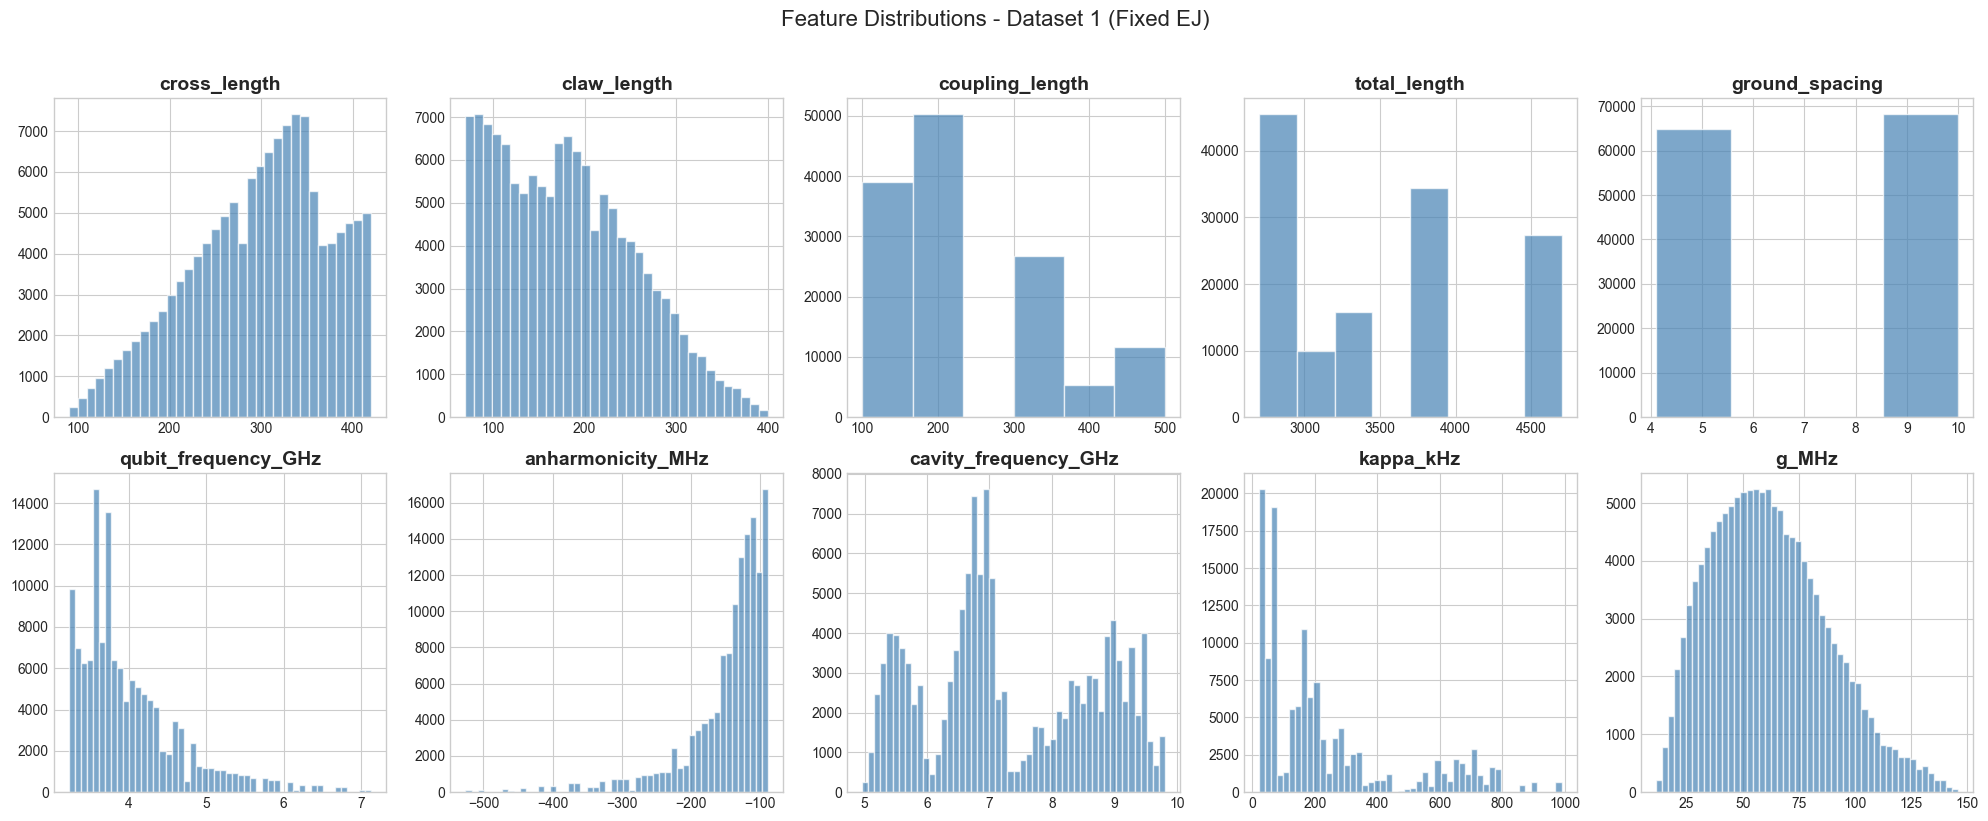

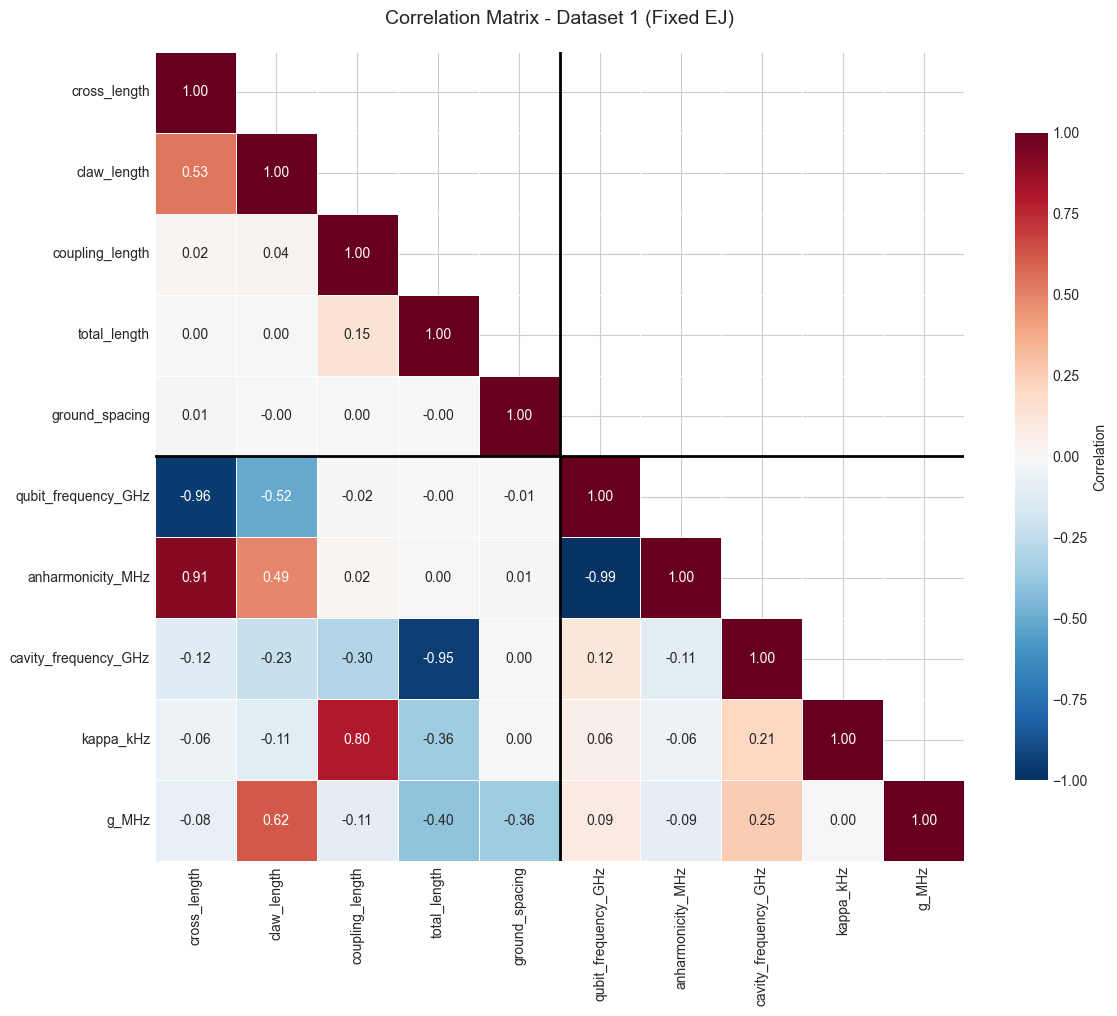

In [8]:
print("Plotting Dataset 1 (Fixed EJ)...")
fig1_dist = plot_distributions(df1, DESIGN_PARAMS_D1, "Dataset 1 (Fixed EJ)")
fig1_dist.savefig(FIG_DIR / 'd1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

fig1_corr = plot_correlation_matrix(df1, DESIGN_PARAMS_D1, "Dataset 1 (Fixed EJ)")
fig1_corr.savefig(FIG_DIR / 'd1_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

Plotting Dataset 2 (Variable EJ)...


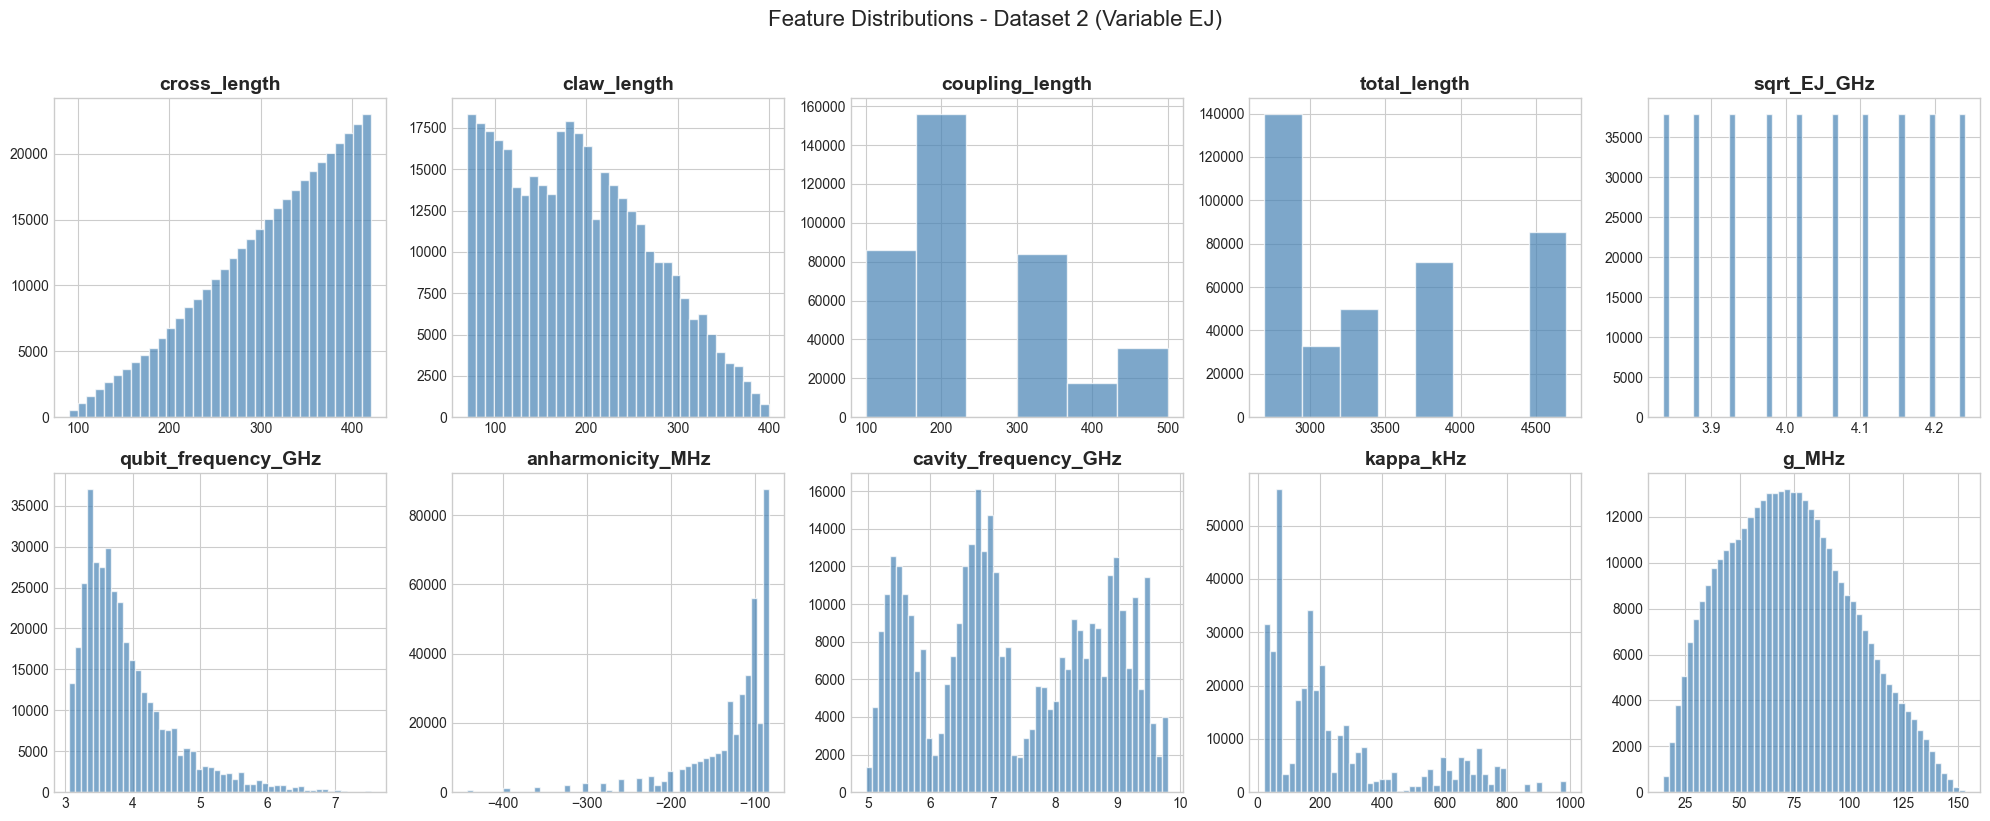

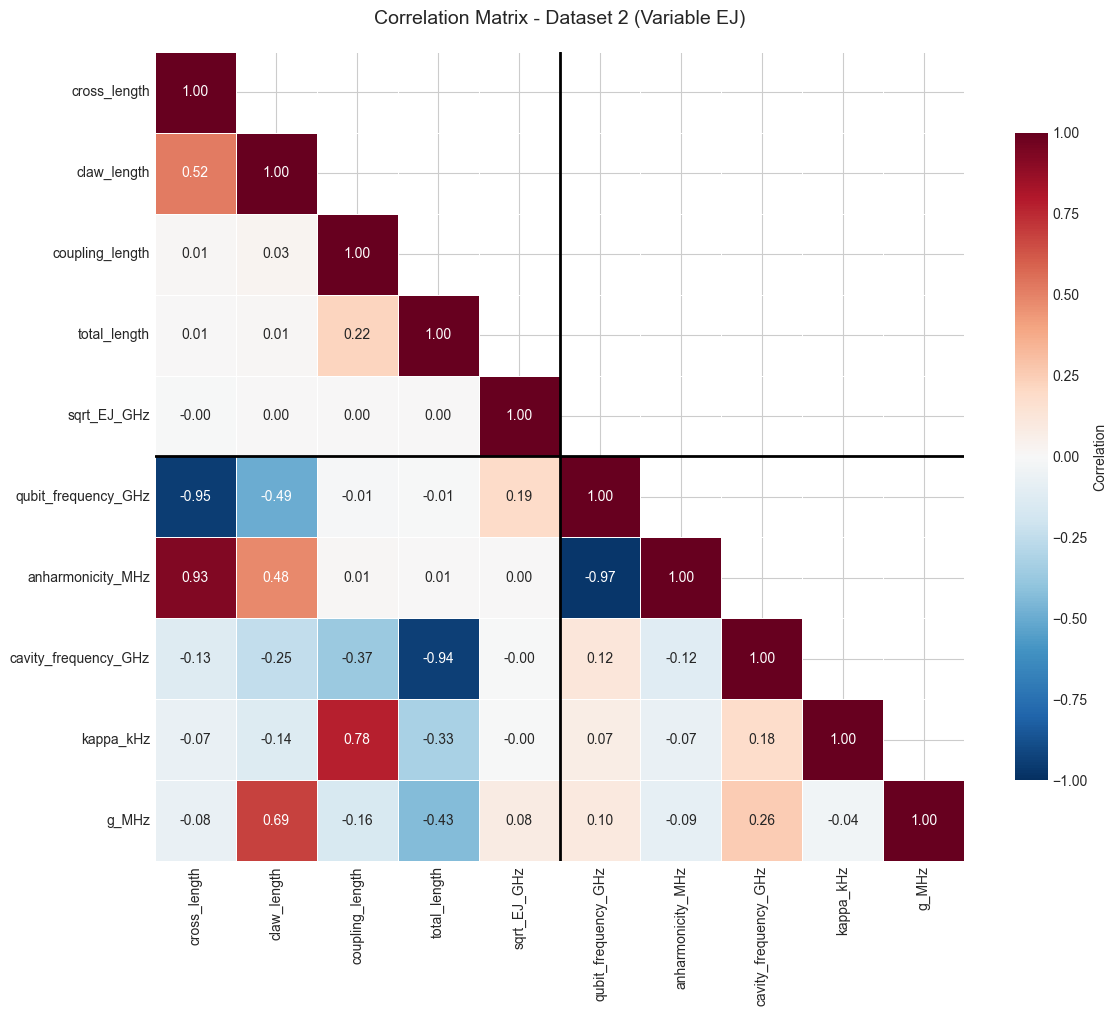

In [9]:
print("Plotting Dataset 2 (Variable EJ)...")
fig2_dist = plot_distributions(df2, DESIGN_PARAMS_D2, "Dataset 2 (Variable EJ)")
fig2_dist.savefig(FIG_DIR / 'd2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

fig2_corr = plot_correlation_matrix(df2, DESIGN_PARAMS_D2, "Dataset 2 (Variable EJ)")
fig2_corr.savefig(FIG_DIR / 'd2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## ML Architecture

We want to have a model that can answer the following questions:

1. Which geometric parameters dominate each Hamiltonian parameter?
2. How do the geometric parameters affect the Hamiltonian parameters?

These two questions can be posed as a feature extraction problem and a regression problem respectively. So, we will use a two-step approach:

1. **EBM Training for Feature Importance**: Train an EBM to learn the importance of each feature.
2 **Symbolic Regression**: Distill the learned importance into a closed-form equation using PySR.

In [10]:
def prepare_train_test(df, design_params):
    """Prepare train-test split for a dataset."""
    X = df[design_params].copy()
    Y = df[HAMILTONIAN_PARAMS].copy()
    
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=RANDOM_STATE
    )
    
    return X_train, X_test, Y_train, Y_test

# Dataset 1
X1_train, X1_test, Y1_train, Y1_test = prepare_train_test(df1, DESIGN_PARAMS_D1)
print(f"Dataset 1: Train={len(X1_train)}, Test={len(X1_test)}")

# Dataset 2
X2_train, X2_test, Y2_train, Y2_test = prepare_train_test(df2, DESIGN_PARAMS_D2)
print(f"Dataset 2: Train={len(X2_train)}, Test={len(X2_test)}")

Dataset 1: Train=106540, Test=26636
Dataset 2: Train=303600, Test=75900


In [13]:
def train_ebm_for_parameter(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    param_name: str,
    max_interaction_bins: int = 32,
    interactions: int = 10,
) -> dict:
    """
    Train an Explainable Boosting Machine for a single Hamiltonian parameter.
    
    Returns:
        Dictionary containing model, metrics, and interpretation data
    """
    print(f"  Training EBM for {param_name}...", end=" ")
    
    ebm = ExplainableBoostingRegressor(
        feature_names=list(X_train.columns),
        max_bins=256,
        max_interaction_bins=max_interaction_bins,
        interactions=interactions,
        outer_bags=8,
        inner_bags=4,
        learning_rate=0.01,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    )
    
    ebm.fit(X_train, y_train)
    
    y_pred_train = ebm.predict(X_train)
    y_pred_test = ebm.predict(X_test)
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    print(f"R²: train={train_r2:.4f}, test={test_r2:.4f}")
    
    return {
        'model': ebm,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'term_names': ebm.term_names_,
        'term_importances': ebm.term_importances(),
    }

In [ ]:
print("="*60)
print("Training EBMs for Dataset 1 (Fixed EJ)")
print("="*60)

ebm_models_d1 = {}
for param in HAMILTONIAN_PARAMS:
    ebm_models_d1[param] = train_ebm_for_parameter(
        X_train=X1_train, y_train=Y1_train[param],
        X_test=X1_test, y_test=Y1_test[param],
        param_name=param,
    )

print("\n" + "="*60)
print("Training EBMs for Dataset 2 (Variable EJ)")
print("="*60)

ebm_models_d2 = {}
for param in HAMILTONIAN_PARAMS:
    ebm_models_d2[param] = train_ebm_for_parameter(
        X_train=X2_train, y_train=Y2_train[param],
        X_test=X2_test, y_test=Y2_test[param],
        param_name=param,
    )

Training EBMs for Dataset 1 (Fixed EJ)
  Training EBM for qubit_frequency_GHz... 

R²: train=1.0000, test=1.0000
  Training EBM for anharmonicity_MHz... R²: train=1.0000, test=1.0000
  Training EBM for cavity_frequency_GHz... R²: train=1.0000, test=1.0000
  Training EBM for kappa_kHz... 

In [ ]:
def plot_ebm_shape_functions(ebm_result, param_name, top_n=5):
    """Plot learned shape functions for a trained EBM."""
    ebm = ebm_result['model']
    term_names = ebm_result['term_names']
    term_importances = ebm_result['term_importances']
    
    sorted_idx = np.argsort(term_importances)[::-1][:top_n]
    
    n_cols = min(3, len(sorted_idx))
    n_rows = (len(sorted_idx) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    else:
        axes = np.array(axes).flatten()
    
    for plot_idx, term_idx in enumerate(sorted_idx):
        ax = axes[plot_idx]
        term_name = term_names[term_idx]
        importance = term_importances[term_idx]
        term_data = ebm.term_scores_[term_idx]
        
        is_2d = hasattr(term_data, 'ndim') and term_data.ndim == 2
        
        if ' x ' in term_name or is_2d:
            if is_2d:
                im = ax.imshow(term_data.T, aspect='auto', origin='lower', cmap='RdBu_r')
                plt.colorbar(im, ax=ax, label='Contribution')
        else:
            ax.plot(term_data, 'b-', linewidth=2)
            ax.fill_between(range(len(term_data)), term_data, alpha=0.3)
            ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        
        ax.set_title(f'{term_name}\n(importance: {importance:.3f})', fontsize=10)
    
    for idx in range(len(sorted_idx), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'EBM Shape Functions: {param_name}', fontsize=12, y=1.02)
    plt.tight_layout()
    return fig

In [ ]:
print("Dataset 1 Shape Functions:")
for param in HAMILTONIAN_PARAMS:
    fig = plot_ebm_shape_functions(ebm_models_d1[param], f"{param} (D1)")
    fig.savefig(FIG_DIR / f'd1_shape_{param}.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
print("\nDataset 2 Shape Functions:")
for param in HAMILTONIAN_PARAMS:
    fig = plot_ebm_shape_functions(ebm_models_d2[param], f"{param} (D2)")
    fig.savefig(FIG_DIR / f'd2_shape_{param}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def analyze_ebm_physics(ebm_models, design_params):
    """Extract feature importance matrix from EBM models."""
    importance_data = {}
    
    for ham_param, result in ebm_models.items():
        term_names = result['term_names']
        term_importances = result['term_importances']
        total_importance = sum(term_importances)
        
        param_importance = {}
        for design_param in design_params:
            importance = 0
            for name, imp in zip(term_names, term_importances):
                if design_param in name:
                    importance += imp / total_importance if total_importance > 0 else 0
            param_importance[design_param] = importance
        
        importance_data[ham_param] = param_importance
    
    return pd.DataFrame(importance_data).T

importance_d1 = analyze_ebm_physics(ebm_models_d1, DESIGN_PARAMS_D1)
importance_d2 = analyze_ebm_physics(ebm_models_d2, DESIGN_PARAMS_D2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(importance_d1, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Feature Importance - Dataset 1 (Fixed EJ)', fontsize=12)

sns.heatmap(importance_d2, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Feature Importance - Dataset 2 (Variable EJ)', fontsize=12)

plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Symbolic Regression

Now, we use PySR to discover closed-form equations from the data.

In [ ]:
def get_features_from_ebm(ebm_result, design_params, threshold=0.05):
    """
    Extract important features from EBM for symbolic regression.
    
    Returns:
        dict with 'base' features and 'interactions' pairs
    """
    term_names = ebm_result['term_names']
    term_importances = ebm_result['term_importances']
    total_importance = sum(term_importances)
    
    base_features = set()
    interaction_pairs = []
    
    for name, importance in zip(term_names, term_importances):
        rel_importance = importance / total_importance if total_importance > 0 else 0
        if rel_importance >= threshold:
            if ' x ' in name:
                features = name.split(' x ')
                if len(features) == 2:
                    f1, f2 = features[0].strip(), features[1].strip()
                    if f1 in design_params and f2 in design_params:
                        interaction_pairs.append((f1, f2))
                        base_features.add(f1)
                        base_features.add(f2)
            elif name in design_params:
                base_features.add(name)
    
    return {'base': list(base_features), 'interactions': interaction_pairs}


def prepare_features_with_interactions(X, base_features, interaction_pairs):
    """Create dataframe with base and interaction features."""
    X_prepared = X[base_features].copy()
    
    for f1, f2 in interaction_pairs:
        if f1 in X.columns and f2 in X.columns:
            X_prepared[f'{f1}_x_{f2}'] = X[f1] * X[f2]
    
    return X_prepared

In [ ]:
def train_symbolic_regressor(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    param_name: str,
    feature_info: dict,
    niterations: int = 50,
    maxsize: int = 15,
    parsimony: float = 0.02,
) -> dict:
    """
    Train a symbolic regression model for a Hamiltonian parameter using RAW physical units for interpretable equations.
    """
    print(f"\n{'='*60}")
    print(f"Symbolic Regression for: {param_name}")
    print(f"{'='*60}")
    
    base_features = feature_info['base']
    interaction_pairs = feature_info['interactions']
    
    X_train_prepared = prepare_features_with_interactions(X_train, base_features, interaction_pairs)
    X_test_prepared = prepare_features_with_interactions(X_test, base_features, interaction_pairs)
    
    feature_names = list(X_train_prepared.columns)
    print(f"Using features: {feature_names}")
    
    model = PySRRegressor(
        niterations=niterations,
        binary_operators=["+", "-", "*", "/"],
        unary_operators=["square", "sqrt", "inv"],
        maxsize=maxsize,
        parsimony=parsimony,
        populations=20,
        population_size=50,
        timeout_in_seconds=300,
        verbosity=1,
    )
    
    model.fit(
        X_train_prepared.values,
        y_train.values,
        variable_names=feature_names,
    )
    
    y_pred = model.predict(X_test_prepared.values)
    test_r2 = r2_score(y_test.values, y_pred)
    test_mae = mean_absolute_error(y_test.values, y_pred)
    
    print(f"\nBest equation: {model.sympy()}")
    print(f"Test R²: {test_r2:.4f}")
    print(f"Test MAE: {test_mae:.4f}")
    
    return {
        'model': model,
        'equation': str(model.sympy()),
        'test_r2': test_r2,
        'test_mae': test_mae,
        'features_used': feature_names,
    }

In [ ]:
symbolic_models_d1 = {}
symbolic_models_d2 = {}

if PYSR_AVAILABLE:
    # Dataset 1
    print("\n" + "#"*60)
    print("SYMBOLIC REGRESSION - Dataset 1 (Fixed EJ)")
    print("#"*60)
    
    for param in HAMILTONIAN_PARAMS:
        feature_info = get_features_from_ebm(ebm_models_d1[param], DESIGN_PARAMS_D1)
        
        if len(feature_info['base']) > 0:
            symbolic_models_d1[param] = train_symbolic_regressor(
                X_train=X1_train, y_train=Y1_train[param],
                X_test=X1_test, y_test=Y1_test[param],
                param_name=param, feature_info=feature_info,
                niterations=50, maxsize=15, parsimony=0.02,
            )
            
            # Save checkpoint
            with open(CHECKPOINT_DIR / f'd1_pysr_{param}.pkl', 'wb') as f:
                pickle.dump(symbolic_models_d1[param], f)
    
    # Dataset 2
    print("\n" + "#"*60)
    print("SYMBOLIC REGRESSION - Dataset 2 (Variable EJ)")
    print("#"*60)
    
    for param in HAMILTONIAN_PARAMS:
        feature_info = get_features_from_ebm(ebm_models_d2[param], DESIGN_PARAMS_D2)
        
        if len(feature_info['base']) > 0:
            symbolic_models_d2[param] = train_symbolic_regressor(
                X_train=X2_train, y_train=Y2_train[param],
                X_test=X2_test, y_test=Y2_test[param],
                param_name=param, feature_info=feature_info,
                niterations=50, maxsize=15, parsimony=0.02,
            )
            
            # Save checkpoint
            with open(CHECKPOINT_DIR / f'd2_pysr_{param}.pkl', 'wb') as f:
                pickle.dump(symbolic_models_d2[param], f)
else:
    print("PySR not available. Skipping symbolic regression.")

In [ ]:
def load_symbolic_models(checkpoint_dir, prefix):
    """Load symbolic models from checkpoint."""
    models = {}
    for param in HAMILTONIAN_PARAMS:
        path = checkpoint_dir / f'{prefix}_pysr_{param}.pkl'
        if path.exists():
            with open(path, 'rb') as f:
                models[param] = pickle.load(f)
            print(f"Loaded {prefix} model for {param}")
    return models

# Uncomment to load from checkpoint:
# symbolic_models_d1 = load_symbolic_models(CHECKPOINT_DIR, 'd1')
# symbolic_models_d2 = load_symbolic_models(CHECKPOINT_DIR, 'd2')

In [ ]:
print("\n" + "="*80)
print("DISCOVERED EQUATIONS COMPARISON")
print("="*80)

for param in HAMILTONIAN_PARAMS:
    print(f"\n{param}:")
    print("-"*60)
    
    if param in symbolic_models_d1:
        eq = symbolic_models_d1[param]['equation']
        r2 = symbolic_models_d1[param]['test_r2']
        print(f"  D1 (Fixed EJ):    {eq}")
        print(f"                    R² = {r2:.4f}")
    else:
        print(f"  D1 (Fixed EJ):    [not trained]")
    
    if param in symbolic_models_d2:
        eq = symbolic_models_d2[param]['equation']
        r2 = symbolic_models_d2[param]['test_r2']
        print(f"  D2 (Variable EJ): {eq}")
        print(f"                    R² = {r2:.4f}")
    else:
        print(f"  D2 (Variable EJ): [not trained]")

##  Results Visualization

In [ ]:
def plot_predictions(models, X_test, Y_test, title_suffix):
    """Plot predicted vs actual for all Hamiltonian parameters."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, param in enumerate(HAMILTONIAN_PARAMS):
        ax = axes[idx]
        
        if param in models:
            model = models[param]['model']
            y_true = Y_test[param].values
            y_pred = model.predict(X_test.values)
            r2 = r2_score(y_true, y_pred)
            
            ax.scatter(y_true, y_pred, alpha=0.3, s=10)
            ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
                   'r--', lw=2, label='Perfect')
            ax.set_xlabel('Actual')
            ax.set_ylabel('Predicted')
            ax.set_title(f'{param}\nR² = {r2:.4f}')
            ax.legend()
        else:
            ax.text(0.5, 0.5, 'Not trained', ha='center', va='center',
                   transform=ax.transAxes)
            ax.set_title(param)
    
    # Hide unused axes
    for idx in range(len(HAMILTONIAN_PARAMS), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'EBM Predictions - {title_suffix}', fontsize=14, y=1.02)
    plt.tight_layout()
    return fig

In [ ]:
fig1 = plot_predictions(ebm_models_d1, X1_test, Y1_test, "Dataset 1 (Fixed EJ)")
fig1.savefig(FIG_DIR / 'd1_ebm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
fig2 = plot_predictions(ebm_models_d2, X2_test, Y2_test, "Dataset 2 (Variable EJ)")
fig2.savefig(FIG_DIR / 'd2_ebm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)

summary_data = []
for param in HAMILTONIAN_PARAMS:
    row = {
        'Parameter': param,
        'D1 EBM R²': ebm_models_d1[param]['test_r2'],
        'D2 EBM R²': ebm_models_d2[param]['test_r2'],
    }
    
    if param in symbolic_models_d1:
        row['D1 SR R²'] = symbolic_models_d1[param]['test_r2']
        row['D1 Equation'] = symbolic_models_d1[param]['equation'][:50] + '...'
    else:
        row['D1 SR R²'] = None
        row['D1 Equation'] = None
    
    if param in symbolic_models_d2:
        row['D2 SR R²'] = symbolic_models_d2[param]['test_r2']
        row['D2 Equation'] = symbolic_models_d2[param]['equation'][:50] + '...'
    else:
        row['D2 SR R²'] = None
        row['D2 Equation'] = None
    
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

Save the models

In [ ]:
# Save EBM models
with open(CHECKPOINT_DIR / 'all_ebm_models_d1.pkl', 'wb') as f:
    pickle.dump(ebm_models_d1, f)
print(f"✓ Saved Dataset 1 EBM models to {CHECKPOINT_DIR / 'all_ebm_models_d1.pkl'}")

with open(CHECKPOINT_DIR / 'all_ebm_models_d2.pkl', 'wb') as f:
    pickle.dump(ebm_models_d2, f)
print(f"✓ Saved Dataset 2 EBM models to {CHECKPOINT_DIR / 'all_ebm_models_d2.pkl'}")

# Save symbolic models (if trained)
if symbolic_models_d1:
    with open(CHECKPOINT_DIR / 'all_symbolic_models_d1.pkl', 'wb') as f:
        pickle.dump(symbolic_models_d1, f)
    print(f"✓ Saved Dataset 1 Symbolic models")

if symbolic_models_d2:
    with open(CHECKPOINT_DIR / 'all_symbolic_models_d2.pkl', 'wb') as f:
        pickle.dump(symbolic_models_d2, f)
    print(f"✓ Saved Dataset 2 Symbolic models")

print("\n✓ Notebook complete!")